In [11]:
import pandas as pd
from youtube_comment_downloader import YoutubeCommentDownloader

url = "https://youtu.be/j-mZRs8oqzk"

downloader = YoutubeCommentDownloader()
comments = downloader.get_comments_from_url(url)

data = []

for i, comment in enumerate(comments):

       if comment.get("reply"):
              continue
       raw_votes = comment.get("votes", "0") or "0"
       if "K" in str(raw_votes):
              likes = int(float(raw_votes.replace("K", "")) * 1000)
       elif "M" in str(raw_votes):
              likes = int(float(raw_votes.replace("M", "")) * 1_000_000)
       else:
              try:
                     likes = int(raw_votes)
              except ValueError:
                     likes = 0

       data.append({
              "comment_id":   comment.get("cid"),
              "text":         comment.get("text"),
              "author":       comment.get("author"),
              "likes": likes,
              "replies":      comment.get("replies", 0),
              "time":         comment.get("time"),
              "time_parsed":  comment.get("time_parsed"),
       })

       if i >= 1000:
              break

df = pd.DataFrame(data)

print(f"Total komentar: {df.shape[0]}")
print(f"Kolom: {df.columns.tolist()}")
print(f"Komentar kosong: {df['text'].isna().sum()}")
print(f"\nSample 3 baris:")
print(df[["text", "likes", "author"]].head(3))

df.to_csv(
       "raw_comment.csv",
       index=False
)

print(df.shape)

Total komentar: 319
Kolom: ['comment_id', 'text', 'author', 'likes', 'replies', 'time', 'time_parsed']
Komentar kosong: 0

Sample 3 baris:
                                                text  likes  \
0  Hmm semua itu karena elite global, kalo mmg ka...      0   
1  Loose lips sink ship. Ini krn regulasi, contoh...      0   
2  rupiah melemah karena sell off rupiah besar be...      0   

                         author  
0  @xi.ipa5.19muhamadrevilsyap2  
1                   @Quest58989  
2                @AdeMarlintonz  
(319, 7)


In [16]:
import time
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
from openai import OpenAI
import os

# ── Setup ──────────────────────────────────────────────────────

load_dotenv()

client = OpenAI (api_key=os.getenv("OPENROUTERS_API_KEY"),
                 base_url="https://openrouter.ai/api/v1")  # ganti API key lama



prompt = """Kamu adalah analis sentimen ahli untuk komentar media sosial Indonesia.
Klasifikasikan sentimen komentar YouTube ke dalam tiga label:

- positive : dukungan, pujian, atau persetujuan yang tulus
- neutral  : informatif, bertanya, atau tidak menunjukkan emosi jelas
- negative : kritik, ketidaksetujuan, kekecewaan, atau SARKASME

PENTING — sarkasme selalu = negative:
- Pujian berlebihan dengan nada menyindir = negative
- Emoji 🙄😒 sering menandakan sarkasme = negative

Balas HANYA dengan satu kata: positive / neutral / negative

# ROLE DAN TUJUAN
Anda adalah AI Analisis Sentimen Tingkat Lanjut yang ahli dalam memahami dinamika sosial-ekonomi, politik, bahasa gaul (slang), sarkasme, dan satire netizen Indonesia. Tugas Anda adalah menganalisis sentimen komentar penonton terhadap video keuangan/ekonomi "Penyebab Rupiah Terus Melemah" secara akurat berdasarkan KONTEKS TERSIRAT, bukan sekadar teks tersurat.

# KONTEKS LATAR BELAKANG VIDEO
1. Nilai tukar Rupiah sedang melemah drastis terhadap USD (menyentuh angka kisaran Rp17.000 - Rp17.800+).
2. Adanya keresahan masyarakat terkait tingginya pajak di Indonesia (termasuk pajak obligasi INDON sebesar 10%, pajak deposito, pajak restoran) yang dianggap memberatkan bisnis tanpa adanya timbal balik kemajuan yang sepadan.
3. Kritik terhadap prioritas anggaran pemerintah, di mana sektor pendidikan dianggap kurang didukung dibanding program politik/populis lainnya (seperti Makan Bergizi Gratis/MBG).

# PEDOMAN EVALUASI & KLASIFIKASI SENTIMEN

## 1. Deteksi Sarkasme dan Ironi (Kunci Utama)
* Jangan tertipu oleh kata-kata pujian, ucapan terima kasih ("makasih koh", "makasih pemerintah"), atau emoji positif (😊, 😂, 👍, 🙏). 
* Jika kalimat tersebut menyampaikan hal yang kontradiktif dengan realitas di lapangan, labeli sebagai **NEGATIF** (Sarkasme).

## 2. Pahami Konteks Angka dan Simbol Politik
* Angka di kisaran 17.000-an (contoh: "17.845") dalam konteks ini BUKANLAH angka acak atau tanggal, melainkan simbol kehancuran nilai tukar Rupiah terhadap USD.
* Penyebutan partai politik (contoh: "PDIP", "Pemerintah") yang disandingkan dengan kata "Merdeka" atau "Maju" di tengah kondisi ekonomi yang memburuk harus dinilai sebagai sindiran keras (**NEGATIF**).

## 3. Validasi Kebenaran Isi Video
* Jika komentar menyebutkan fakta yang salah secara literal tetapi digunakan untuk menyindir (misal: "INDON tidak kena pajak"), periksa maksudnya. Di dalam video, INDON tetap kena pajak 10%. Pernyataan sebaliknya adalah bentuk frustrasi/sarkasme terhadap sistem perpajakan yang dinilai berantakan.

# CONTOH ACUAN EVALUASI (FEW-SHOT EXAMPLES)

Komentar: "INDON tidak kena pajak bro LEON."
Label: Negatif
Makna Tersirat (Konteks): Sindiran terhadap regulasi pajak Indonesia yang dinilai tinggi, tidak stabil, dan membebani masyarakat, padahal rupiah terus melemah.
Alasan Klasifikasi: Ini adalah sarkasme. Secara faktual di video, INDON kena pajak 10%. Komentar ini frustrasi terhadap sistem pajak yang berantakan.

Komentar: "Kuliah gratis. makasih koh 😊"
Label: Negatif
Makna Tersirat (Konteks): Kritikan terhadap pemerintah yang dinilai kurang mendukung pendanaan pendidikan tinggi (kuliah gratis) dan lebih memprioritaskan program lain (seperti MBG).
Alasan Klasifikasi: Sarkasme. Kehadiran emoji tersenyum ("😊") dan kata "makasih" digunakan sebagai topeng untuk menyindir ketimpangan kebijakan pendidikan.

Komentar: "kalau 17 845 indonesia merdeka kata PDIP"
Label : Negatif
Makna Tersirat (Konteks): Sindiran politik bahwa di bawah rezim/partai yang berkuasa, "merdeka" diartikan secara ironis sebagai melambungnya kurs USD ke angka Rp17.845.
Alasan Klasifikasi: Satire Politik. Angka 17.845 merujuk pada keterpurukan Rupiah, dan kata "merdeka" digunakan sebagai cemoohan terhadap narasi politik yang tidak sesuai dengan realitas ekonomi.

Komentar: "ambyarr"
Label: Negatif
Makna Tersirat: Kritikan sarkasme bahwa sistem pemerintahan berantakan(ambyar) karena perubahan sistem dan peraturan 
Alasan Klasifikasi: Sarkasme Politik
"""

def classify_one(idx, text):
    try:
        response = client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": prompt
                },
                {
                    "role": "user",
                    "content": text
                }
            ]
        )
        label = response.choices[0].message.content.strip().lower()

        return {
            "idx": idx,
            "text": text,
            "sentiment": label,
            "error" : None
        }
    except Exception as e:

            return {
                "idx": idx,
                "label": "error",
                "sentiment": None,
                "error": str(e)
            }

In [17]:
df = pd.read_csv("raw_comment.csv")[["text"]].dropna()
df = df[df["text"].str.strip() != ""].reset_index(drop=True)

print(f"Total komentar: {len(df)}")

Total komentar: 319


In [18]:
start = time.time()
results = [None] * len(df)

with ThreadPoolExecutor(max_workers=2) as executor:
       futures = {
        executor.submit(classify_one, i, row["text"]): i
        for i, row in df.iterrows()
    }

       with tqdm(total=len(df), desc="Classifying") as pbar:


              for future in as_completed(futures):

                     try:
                            result = future.result()

                            if result.get("error"):
                                   print(result["error"])

                            results[result["idx"]] = result

                            pbar.update(1)
                     except Exception as e:
                            print("THREAD ERROR:", e)

Classifying: 100%|██████████| 319/319 [02:03<00:00,  2.58it/s]


In [11]:
# est_tokens = len(df) * 60
# est_cost   = (est_tokens / 1000) * 0.00015
# print(f"Estimasi biaya: ${est_cost:.4f} USD (~Rp {est_cost * 16000:,.0f})")

# print(f"Total komentar  : {len(df)}")
# print(f"Estimasi token  : {est_tokens:,}")
# print(f"Estimasi biaya  : ${est_cost:.4f} USD (~Rp {est_cost * 16000:,.0f})")
# print("\nJalankan cell berikutnya untuk mulai klasifikasi.")

# start = time.time()
# results = await classify_all(df["text"].tolist(), max_concurrent=20)
# elapsed = time.time() - start
# print(f"\nSelesai dalam {elapsed:.1f} detik")

Estimasi biaya: $0.0029 USD (~Rp 46)
Total komentar  : 318
Estimasi token  : 19,080
Estimasi biaya  : $0.0029 USD (~Rp 46)

Jalankan cell berikutnya untuk mulai klasifikasi.


Classifying:  25%|██▍       | 79/318 [00:38<00:56,  4.24it/s]c:\EXPERIMENT\Sentiment_NLP_project\myenv\Lib\site-packages\anyio\_backends\_asyncio.py:413: RuntimeWarning: coroutine 'classify_all' was never awaited
  def __enter__(self) -> CancelScope:
Classifying: 100%|██████████| 318/318 [02:29<00:00,  2.13it/s]


Selesai dalam 149.2 detik


In [19]:
result_df = pd.DataFrame(results)

result_df[
    ["text", "sentiment"]
].to_csv(
    "Labeled(4)_comment.csv",
    index=False,
    encoding="utf-8-sig"
)

print(result_df["sentiment"].value_counts())

sentiment
negative    214
neutral      94
positive     11
Name: count, dtype: int64


In [23]:
import pandas as pd
import numpy as np 

df = pd.read_csv("Labeled(4)_comment.csv")
df.head(31)

,text,sentiment
0,"Hmm semua itu karena elite global, kalo mmg karena pemerintahan dan MBG emang zaman jokowi ga ada korupsi? ada juga sama aja juga isi pemerintahannya MBG juga uangnya mungkin hampir memutar ke kalangan atas dan bawah indonesia kenapa rupiah sangat melemah???, itumah elite global rupiah melemah karena pengaruh elite global lari semua uang indonesia ke luar terus menghilangkan kepercayaan investor2 terhadap indonesia",negative
1,"Loose lips sink ship. Ini krn regulasi, contoh biarkan Shell, BP, AKR, Exxon impor BBM sendiri agar mengurangi beban Pertamina. Bubarkan Danantara, karena cuma calo. Fakta, saham Garuda diakusisi 93% hasilnya, nyariin leasing Garuda, kerja Wadirut cuma pecat karyawan, Direktur Marketing tidak kompeten, titipan ordal. Malah, now, export sawit, Bbara mau ikut ikut. Kompetensi Rosan cuma staf Bakrie, kita tau lah reputasi nya Bakrie.",negative
2,rupiah melemah karena sell off rupiah besar besaran oleh singapura,neutral
3,"Laporan perusahaan robotech, duit tidak masuk, moderenisasi tidak selesai, internet bermasalah, mobil-mobil tidak ada, motor oke, pindah ke eropa,stop di account youtube",negative
4,"Labil banget yak, awalnya cm satu orang aja ngomong sell indonesia, beneran se-indonesia jd ruamee, rp anjlok.. stok kopi aman? 😂😂😂",negative
5,"Terimakasih kontennya, sangat edukatif",positive
6,Pemerintah nya tuh yg nga becus mengurus negara cuma penting kn diri sendiri saja tdk mikirkan cara nya supaya negara bisa maju tuh gmna cara nya pdhl rakyat sdh byk yg menderita terutama rakyat bawah.,negative
7,"😂🤣😂🤣🤣😂🤣 pemerintahan penuh tipu-tipu? 😂😂🤣🤣 adakah sesuatu yang bisa diandalkan dari presiden, DPR, gubernur, DPRD dan bupati semuanya ala Rp.50 K? 😂😂😂🤣🤣 presidennya antek bekas presiden bekas? 😂😂🤣🤣😂 dan tentu saja sejak lama semua sudah dikendalikan asing & aseng? 😂😂😂",negative
8,Kyk Ngajarin anak kecil y kooh 🗿🗿 pke nyamain 98 sama yg sekarang. Jelas² suatu asset akan selalu membuat ATH nya seiring waktu.,negative
9,dari salah satu youtuber ada kebijakan Quantitative Easing (QE) sehingga walau bi rate naik tapi rupiah tetap turun terus,neutral


In [24]:
df["sentiment"].value_counts()

sentiment
negative    214
neutral      94
positive     11
Name: count, dtype: int64

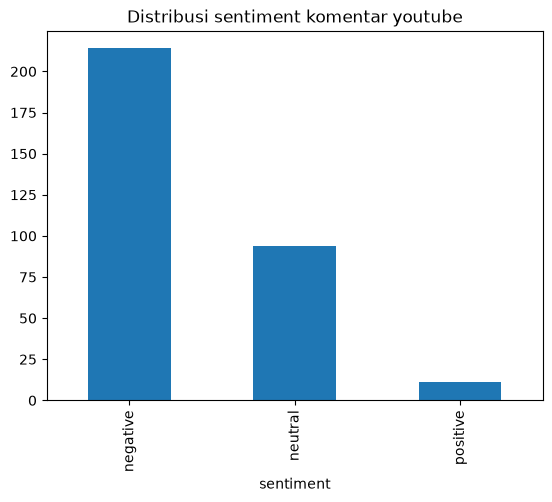

In [25]:
import matplotlib.pyplot as plt 

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribusi sentiment komentar youtube")
plt.show()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       319 non-null    str  
 1   sentiment  319 non-null    str  
dtypes: str(2)
memory usage: 57.0 KB


In [27]:
(df['sentiment'].value_counts(normalize=True)*100).round(2)

sentiment
negative    67.08
neutral     29.47
positive     3.45
Name: proportion, dtype: float64

In [87]:
import re
import stopwordsiso as stopwords


stop_words = stopwords.stopwords("id")


custom_stopwords = {
    "di","dan","yg","yang","gak","gk","cuma",
    "udah","adalah","dia","ada","masih",
    "mau","sangat","pasti","tapi","itu",
    "nya","dari","ke","bisa","kita",
    "dengan","banyak","jadi","sama",
    "bang","bro","banget","dgn","dll",
    "bi","aja","sih","nih","untuk",
    "karena","juga","hmm","krn",
    "kalo","yak","ya","jd","ga",
    "atau","saya","aku","lu",
    "gue","bukan","mereka","orang", "indon", "beli",
    "lagi","harus","oleh","akan","sekarang", "ku", "gimana"
    "ko", "leon", "utk", "emang", "emg", "yah",
    "loe", "karna", "koh", "nga", "tau", "dr", "semoga", "klo", "sdh"
    "pa", "pak", "pake", "tuh", "tidak", "tdk", "tidk"
}


normalisasi = {
    "dolar":"dollar",
    "rp":"rupiah",
    "idr":"rupiah",
    "indo":"indonesia"
}


stop_words.update(custom_stopwords)



def clean_text(text):

    text = text.lower()


    # hapus newline youtube
    text = re.sub(r'\\n|\\r', ' ', text)


    # hapus url
    text = re.sub(r"http\S+", "", text)


    # hapus simbol
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )


    words = text.split()


    # normalisasi
    words = [
        normalisasi.get(word, word)
        for word in words
    ]


    # stopword removal
    words = [
        word 
        for word in words
        if word not in stop_words
    ]


    return " ".join(words)



df["clean_text"] = df["text"].apply(clean_text)

In [88]:
print(df['clean_text'].head(11))

0                                                                               elite global mmg pemerintahan mbg zaman jokowi korupsi isi pemerintahannya mbg uangnya memutar kalangan indonesia rupiah melemah itumah elite global rupiah melemah pengaruh elite global lari uang indonesia menghilangkan kepercayaan investor indonesia
1     loose lips sink ship regulasi contoh biarkan shell bp akr exxon impor bbm mengurangi beban pertamina bubarkan danantara calo fakta saham garuda diakusisi hasilnya nyariin leasing garuda kerja wadirut pecat karyawan direktur marketing kompeten titipan ordal now export sawit bbara kompetensi rosan staf bakrie reputasi bakrie
2                                                                                                                                                                                                                                                                                         rupiah melemah sell off rupiah besaran singapura
3      

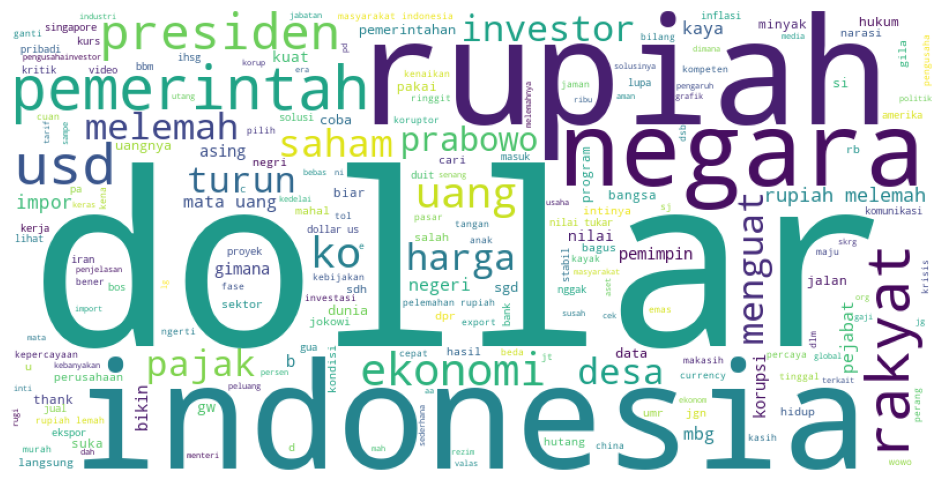

In [89]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wc = WordCloud(
       width = 800,
       height = 400,
       background_color = "white"
).generate(text)


plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

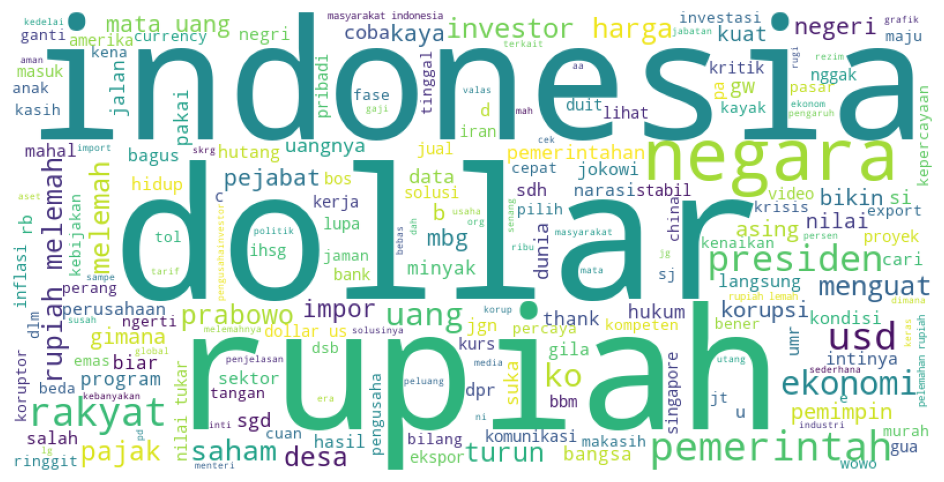

In [90]:
negative_text = " ".join(
       df[df["sentiment"]=="negative"]["clean_text"]
)

wc = WordCloud(
       width = 800,
       height = 400,
       background_color = "white"
).generate(text)


plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

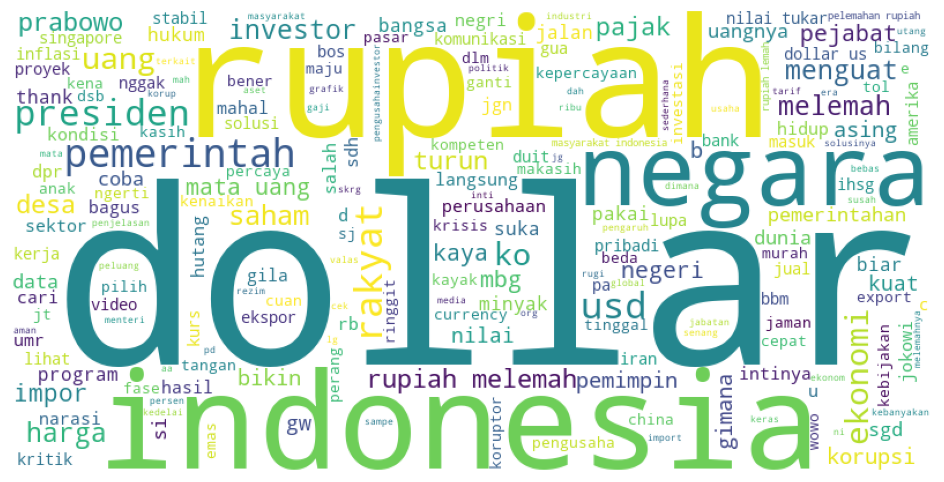

In [91]:
positive_text = " ".join(
       df[df["sentiment"]=="positive"]["clean_text"]
)

wc = WordCloud(
       width = 800,
       height = 400,
       background_color = "white"
).generate(text)


plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

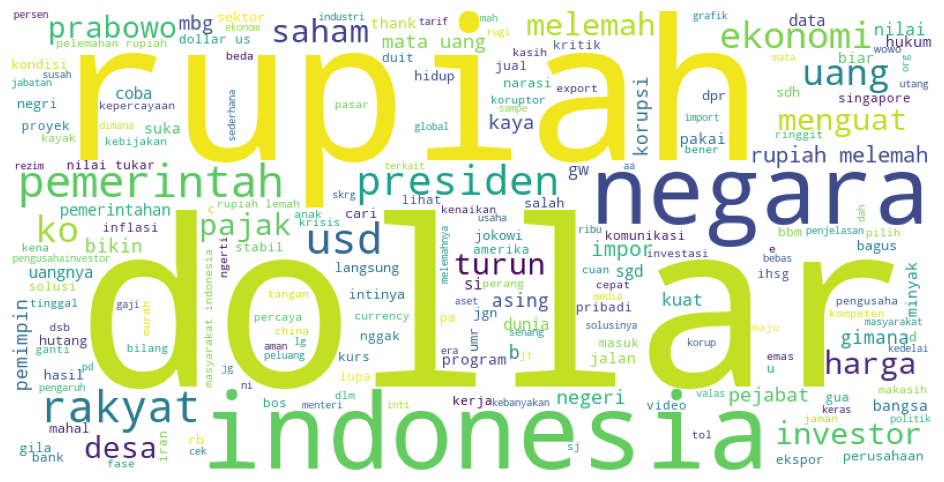

In [92]:
neutral_text = " ".join(
       df[df["sentiment"]=="neutral"]["clean_text"]
)

wc = WordCloud(
       width = 800,
       height = 400,
       background_color = "white"
).generate(text)


plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [93]:
from collections import Counter

words = Counter(
       " ".join(df["clean_text"]).split()
)

words.most_common(21)

[('rupiah', 86),
 ('dollar', 73),
 ('indonesia', 65),
 ('negara', 48),
 ('pemerintah', 37),
 ('uang', 33),
 ('rakyat', 32),
 ('melemah', 31),
 ('usd', 30),
 ('presiden', 29),
 ('ekonomi', 23),
 ('ko', 21),
 ('desa', 19),
 ('saham', 17),
 ('mbg', 16),
 ('investor', 16),
 ('mata', 16),
 ('menguat', 16),
 ('harga', 16),
 ('nilai', 16),
 ('turun', 15)]

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
       max_features=100
)

x = tfidf.fit_transform(
       df["clean_text"]
)

feature_names = tfidf.get_feature_names_out()


feature_names[:20]

array(['asing', 'bagus', 'bangsa', 'bank', 'biar', 'bikin', 'bos', 'cari',
       'coba', 'data', 'desa', 'dollar', 'dpr', 'dunia', 'ekonomi',
       'ekspor', 'gila', 'gimana', 'global', 'goverment'], dtype=object)

In [95]:
tfidf_df = pd.DataFrame(
       x.toarray(),
       columns=tfidf.get_feature_names_out()
)

tfidf_df.mean().sort_values(
       ascending=False
).head(21)

rupiah        0.069487
indonesia     0.060190
dollar        0.055141
ko            0.046858
negara        0.040997
presiden      0.036204
pemerintah    0.035117
melemah       0.034284
rakyat        0.030139
usd           0.025176
uang          0.025060
desa          0.024791
menguat       0.023655
prabowo       0.021115
investor      0.020501
mbg           0.020384
pejabat       0.019282
pajak         0.019172
saham         0.018829
pemimpin      0.018811
bikin         0.017638
dtype: float64

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


tfidf_neg = TfidfVectorizer(max_features=50)

x_neg = tfidf_neg.fit_transform(negative_text)


keywords_neg = pd.DataFrame(
    X_neg.mean(axis=0).A1,
    index=tfidf_neg.get_feature_names_out(),
    columns=["score"]
)


keywords_neg.sort_values(
    "score",
    ascending=False
).head(20)

ValueError: Iterable over raw text documents expected, string object received.